In [2]:
import zipfile
import os

with zipfile.ZipFile("brain_tumor.zip", 'r') as zip_ref:
    zip_ref.extractall("brain_tumor")


In [3]:
os.listdir("brain_tumor")

['Training', 'Testing']

In [4]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

In [5]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [6]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [7]:
tr_df = train_df('/content/brain_tumor/Training')

In [8]:
tr_df

,Class Path,Class
0,/content/brain_tumor/Training/no_tumor/image(3...,no_tumor
1,/content/brain_tumor/Training/no_tumor/image(1...,no_tumor
2,/content/brain_tumor/Training/no_tumor/image (...,no_tumor
3,/content/brain_tumor/Training/no_tumor/image(6...,no_tumor
4,/content/brain_tumor/Training/no_tumor/image(6...,no_tumor
...,...,...
2865,/content/brain_tumor/Training/pituitary_tumor/...,pituitary_tumor
2866,/content/brain_tumor/Training/pituitary_tumor/...,pituitary_tumor
2867,/content/brain_tumor/Training/pituitary_tumor/...,pituitary_tumor
2868,/content/brain_tumor/Training/pituitary_tumor/...,pituitary_tumor


In [9]:
ts_df = test_df('/content/brain_tumor/Testing')

In [10]:
ts_df

,Class Path,Class
0,/content/brain_tumor/Testing/no_tumor/image(3)...,no_tumor
1,/content/brain_tumor/Testing/no_tumor/image(65...,no_tumor
2,/content/brain_tumor/Testing/no_tumor/image(62...,no_tumor
3,/content/brain_tumor/Testing/no_tumor/image(83...,no_tumor
4,/content/brain_tumor/Testing/no_tumor/image(63...,no_tumor
...,...,...
389,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
390,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
391,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
392,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor


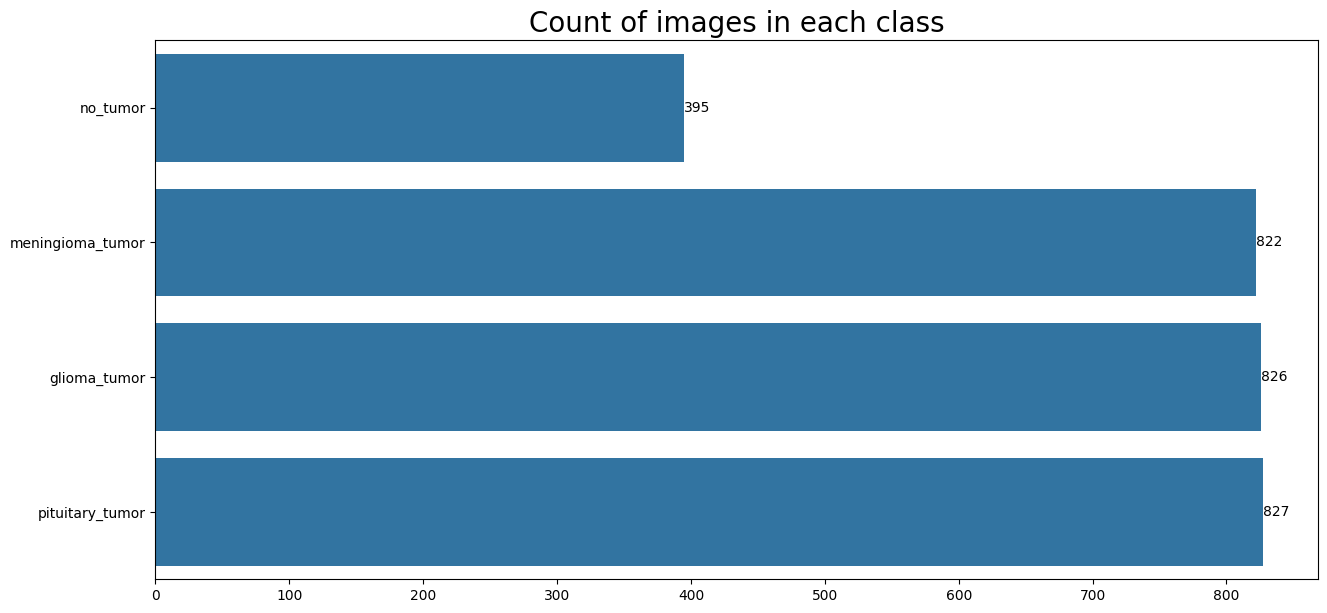

In [11]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

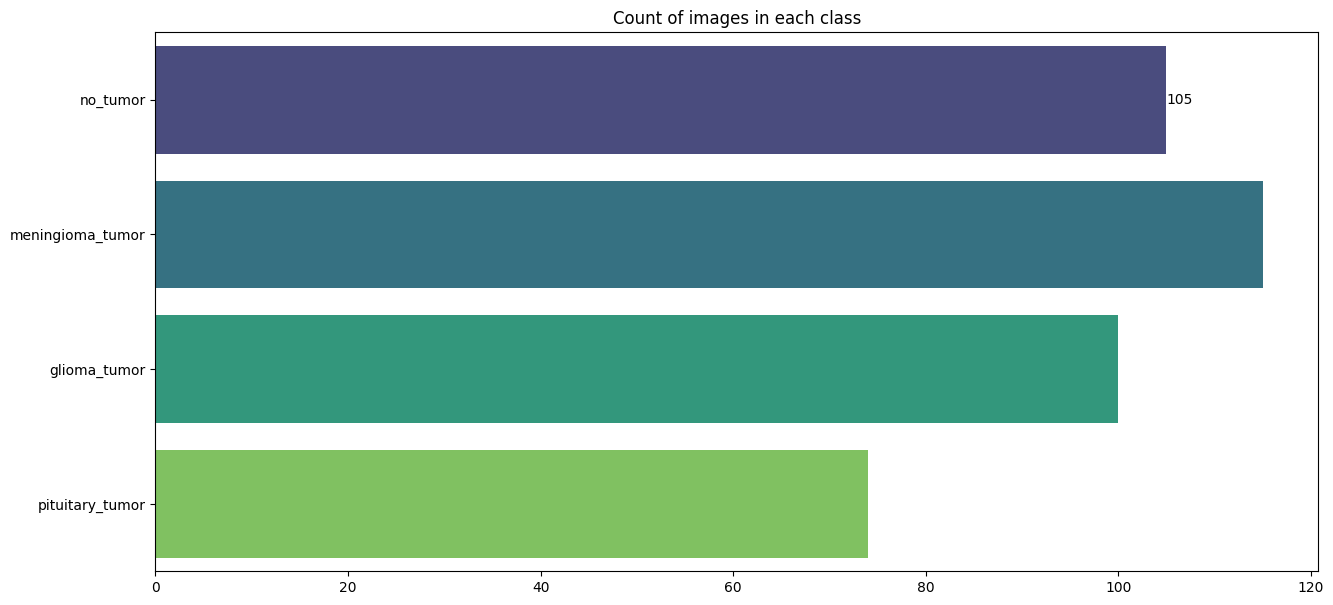

In [12]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

In [13]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [14]:
valid_df

,Class Path,Class
61,/content/brain_tumor/Testing/no_tumor/image(41...,no_tumor
369,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
250,/content/brain_tumor/Testing/glioma_tumor/imag...,glioma_tumor
354,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
45,/content/brain_tumor/Testing/no_tumor/image(89...,no_tumor
...,...,...
258,/content/brain_tumor/Testing/glioma_tumor/imag...,glioma_tumor
376,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
339,/content/brain_tumor/Testing/pituitary_tumor/i...,pituitary_tumor
106,/content/brain_tumor/Testing/meningioma_tumor/...,meningioma_tumor


In [15]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 2870 validated image filenames belonging to 4 classes.
Found 197 validated image filenames belonging to 4 classes.
Found 197 validated image filenames belonging to 4 classes.


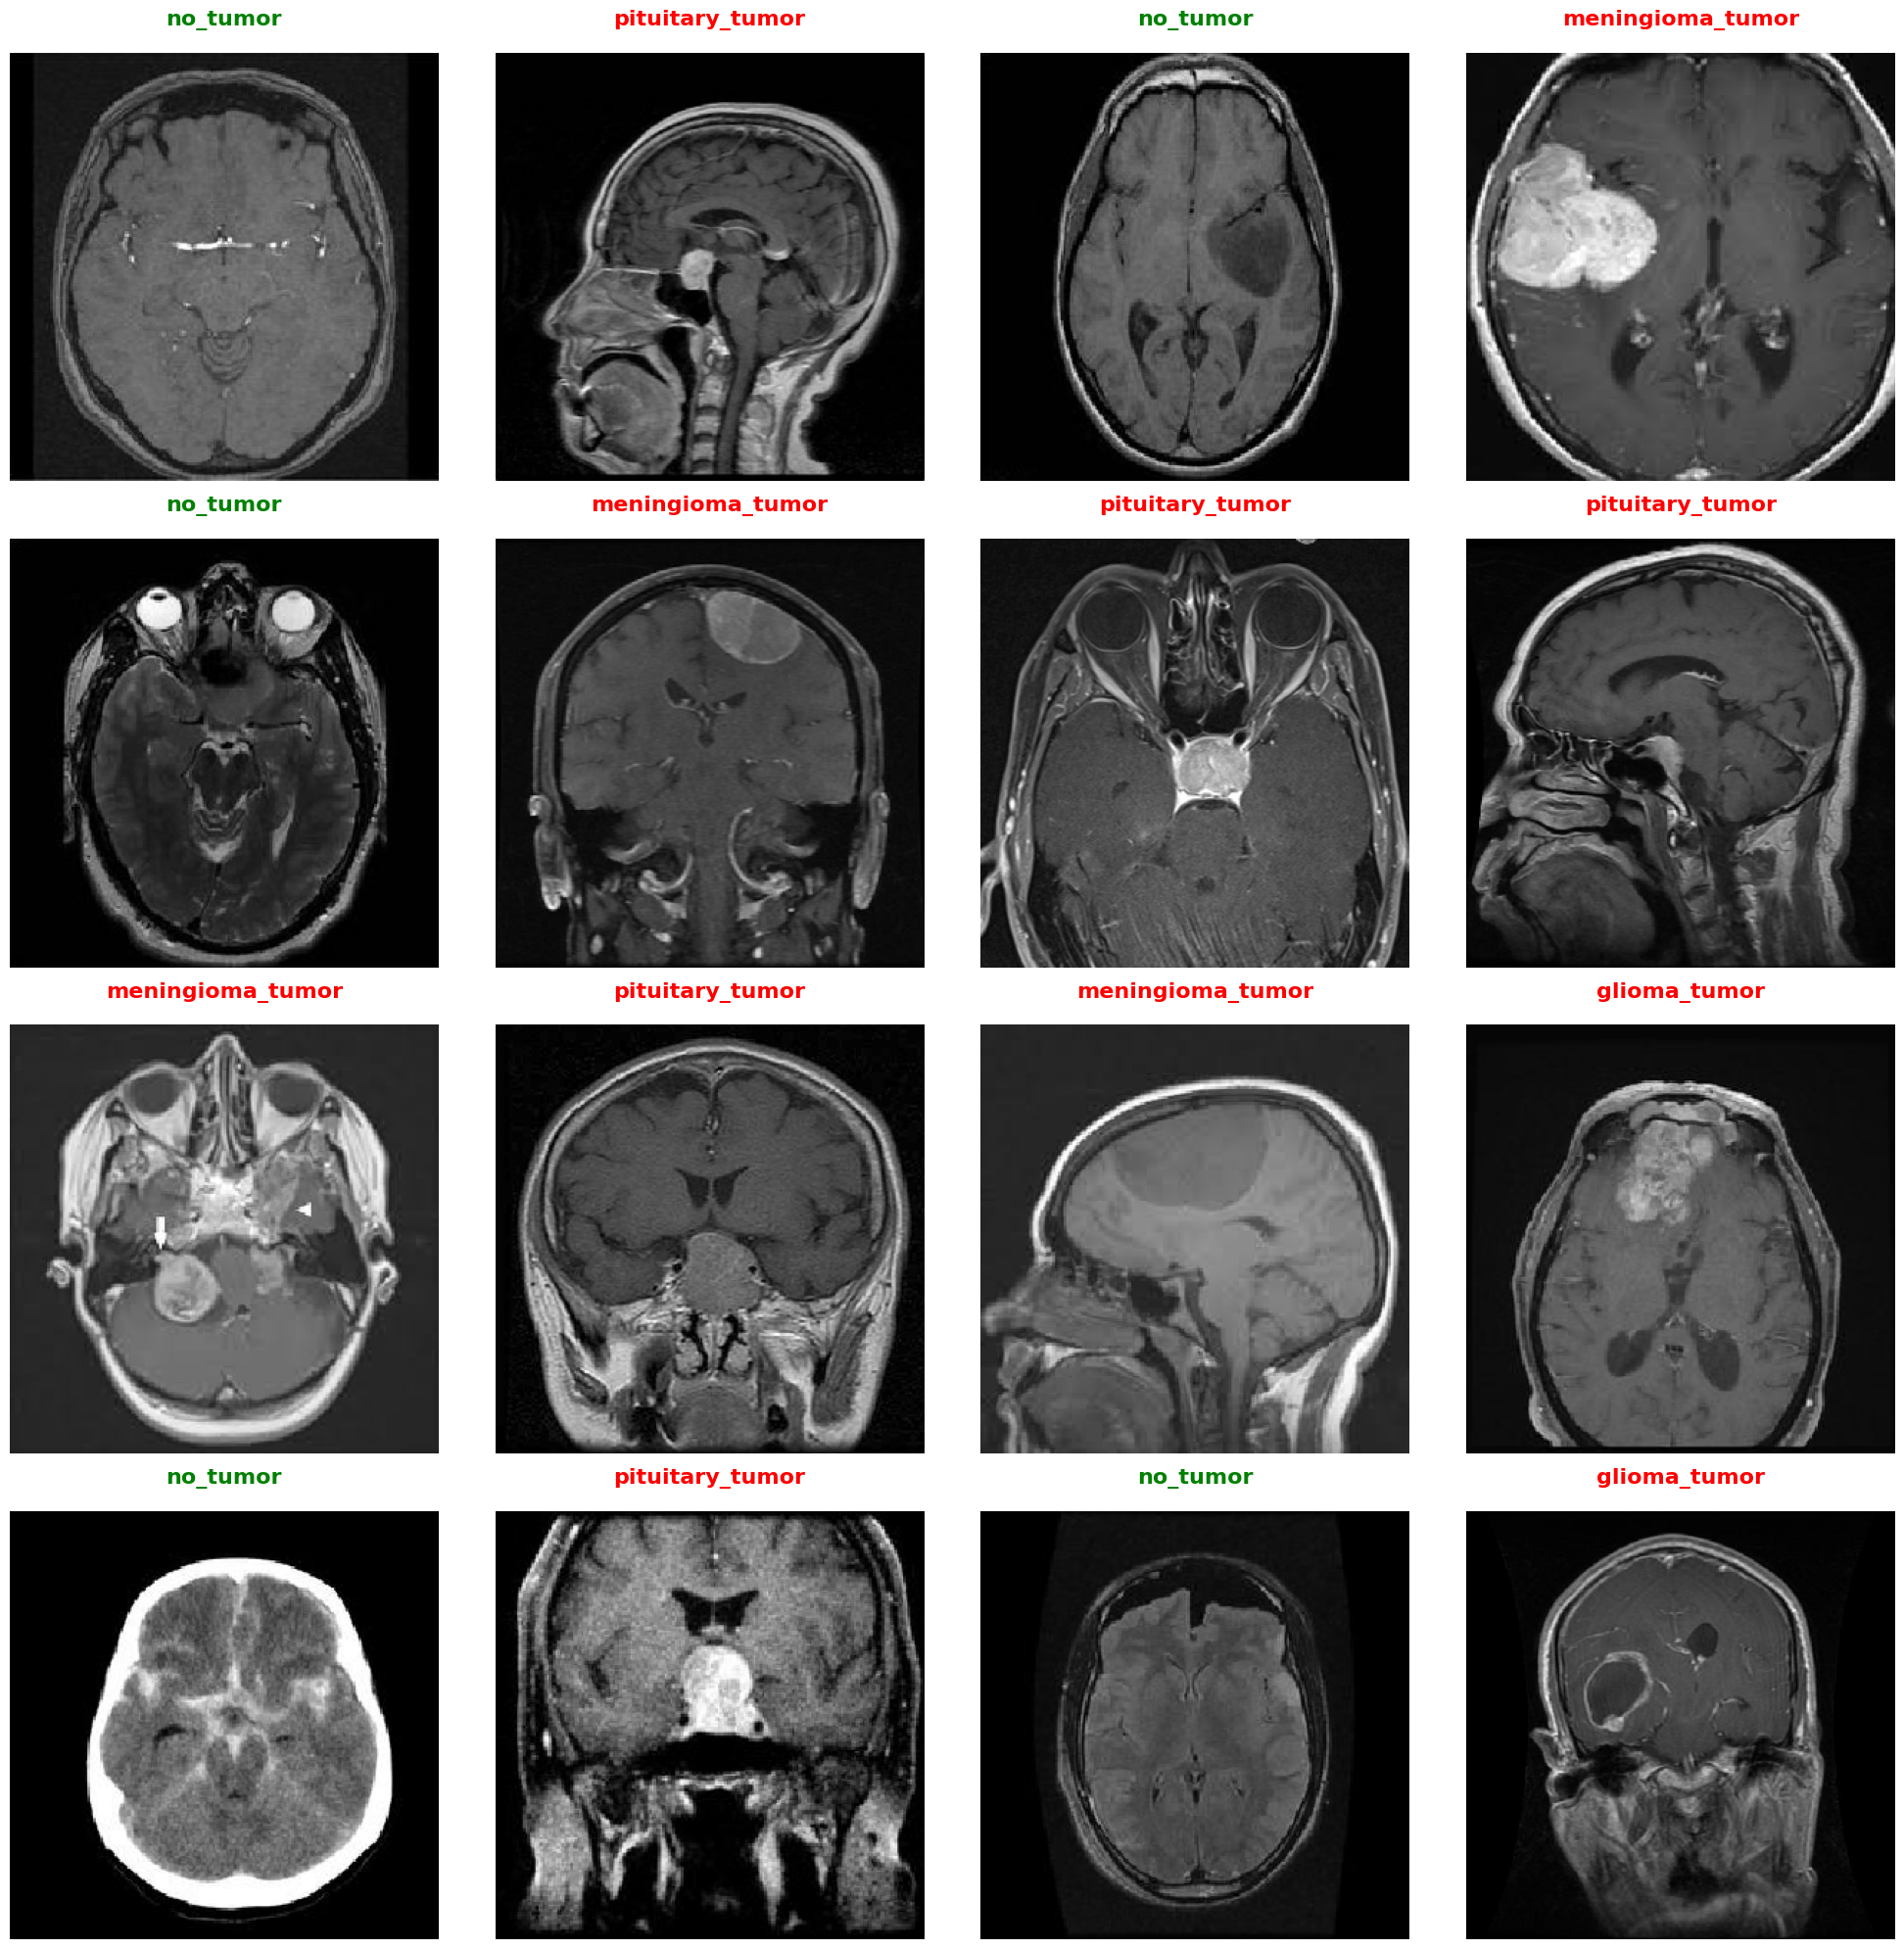

In [20]:
from matplotlib import pyplot as plt
from matplotlib import rcParams
import numpy as np

# Get class names
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())

# Get images and labels
images, labels = next(ts_gen)

# Ensure images are in correct range
if np.max(images) > 1:
    images = images / 255.0

# Plot settings
rcParams['axes.titlepad'] = 20
plt.figure(figsize=(20, 20))

# Plot only as many images as available
num_images = min(len(images), 16)

for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    image = images[i]


    if image.shape[0] <= 3 and image.ndim == 3 and image.shape[0] != image.shape[-1]:
        image = np.transpose(image, (1, 2, 0))

    plt.imshow(image)

    class_index = np.argmax(labels[i])
    class_name = classes[class_index]

    color = 'green' if class_name.lower() == 'no_tumor' else 'red'
    plt.title(class_name, fontsize=16, fontweight='bold', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

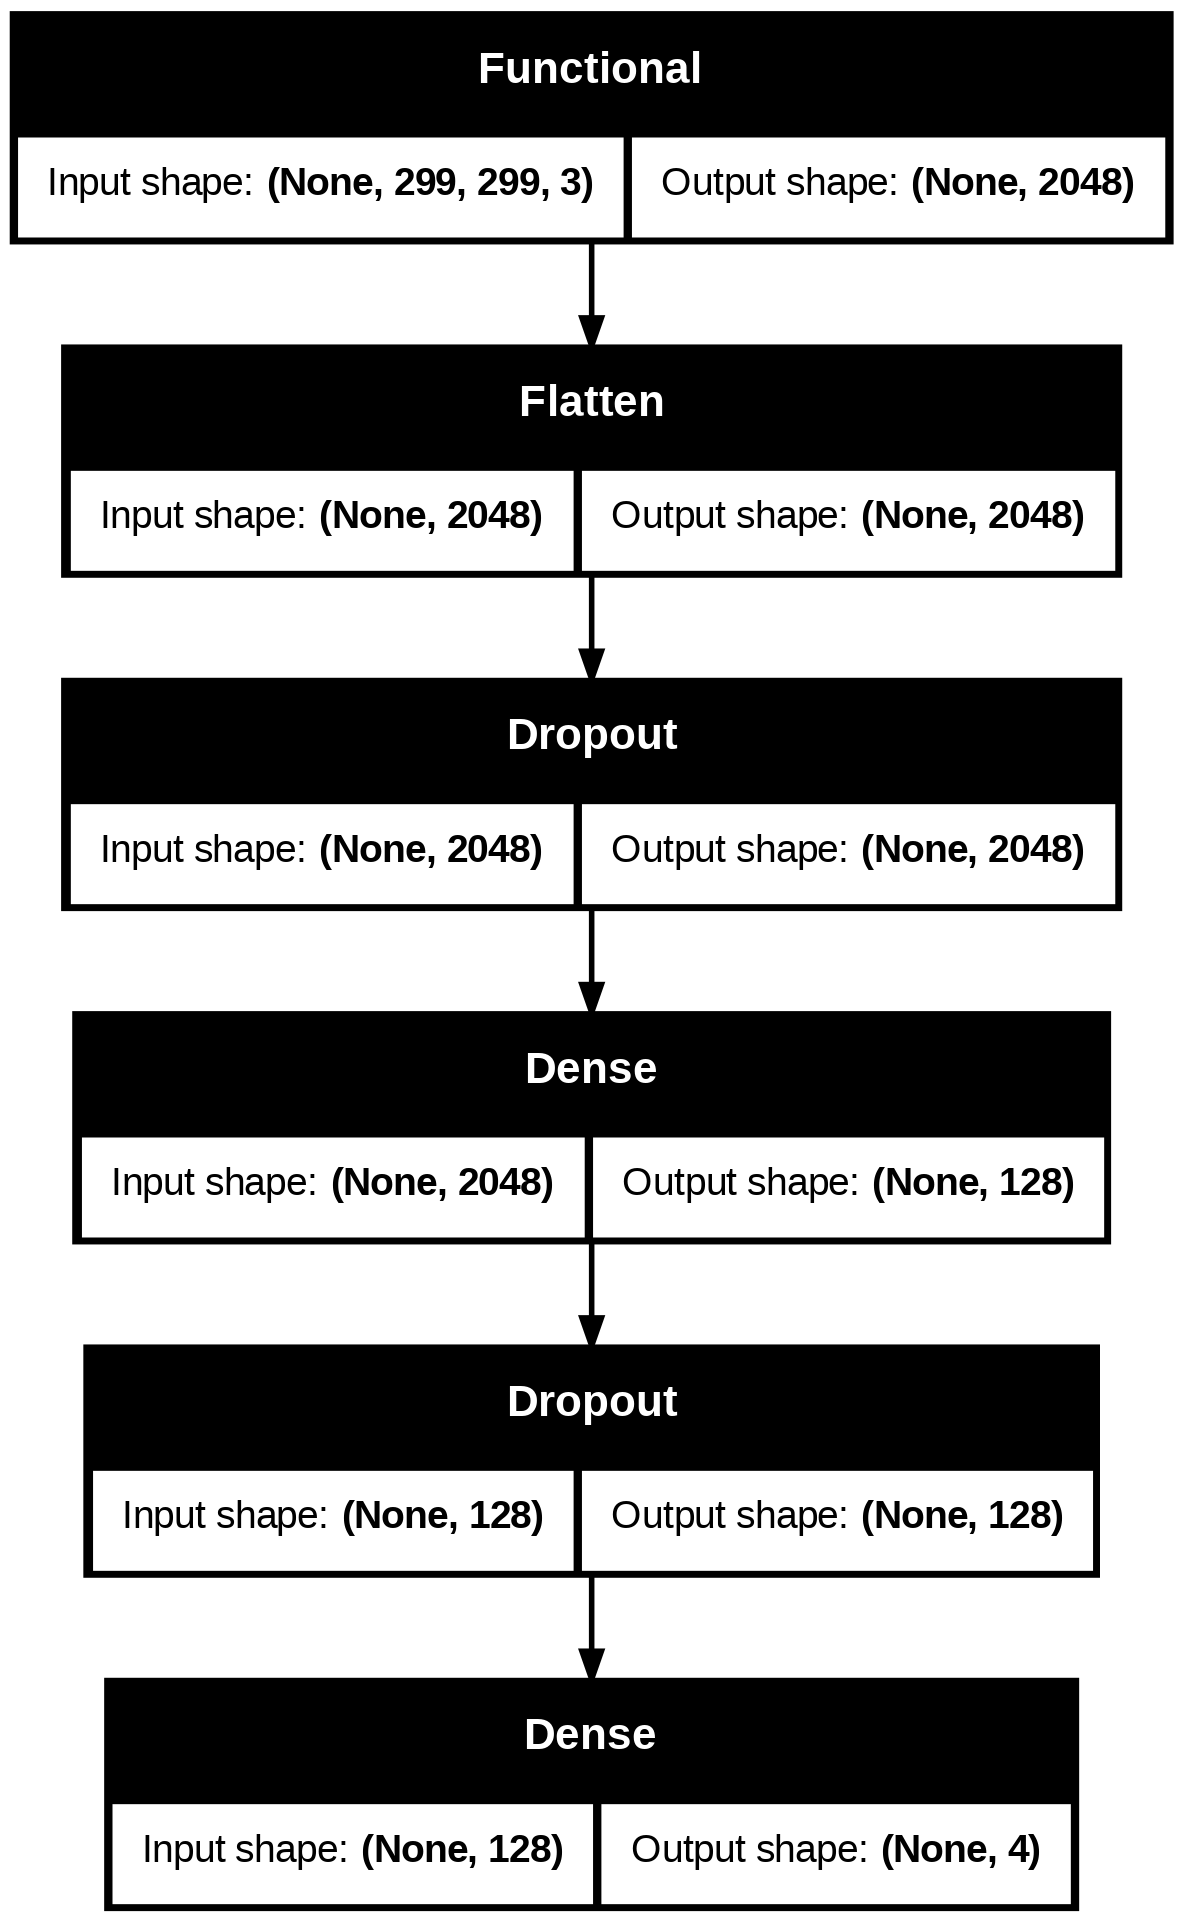

In [22]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [23]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.6422 - loss: 1.0679 - precision: 0.7282 - recall: 0.4624 - val_accuracy: 0.6193 - val_loss: 1.5982 - val_precision: 0.6224 - val_recall: 0.6193
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 77s 853ms/step - accuracy: 0.9634 - loss: 0.1141 - precision: 0.9660 - recall: 0.9593 - val_accuracy: 0.7563 - val_loss: 1.1456 - val_precision: 0.7592 - val_recall: 0.7360
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 847ms/step - accuracy: 0.9822 - loss: 0.0450 - precision: 0.9825 - recall: 0.9817 - val_accuracy: 0.7970 - val_loss: 1.2665 - val_precision: 0.8128 - val_recall: 0.7716
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 846ms/step - accuracy: 0.9931 - loss: 0.0222 - precision: 0.9931 - recall: 0.9931 - val_accuracy: 0.7766 - val_loss: 1.4407 - val_precision: 0.7744 - val_recall: 0.7665
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 846ms/step - accuracy: 0.9892 - loss: 0.0284 - precision: 0.9895 - recall: 0.9888 - val_accuracy: 0.7716 - val_loss:

In [24]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

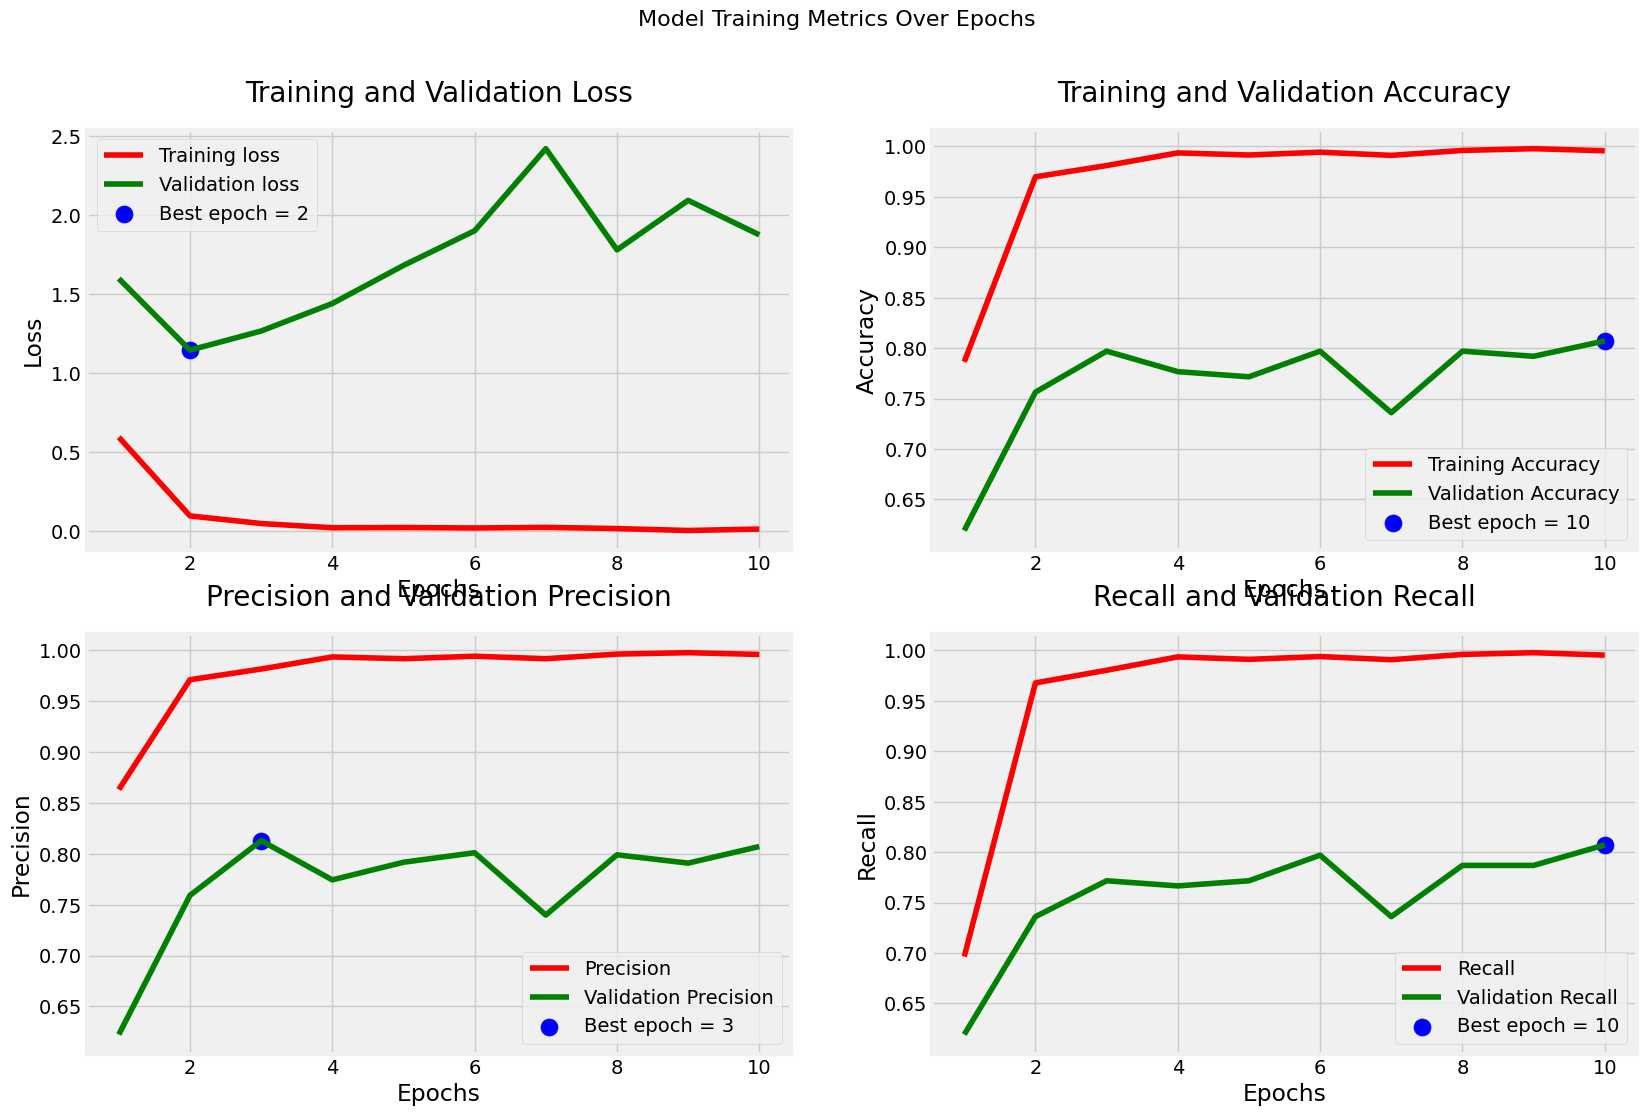

In [25]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

In [26]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 266ms/step - accuracy: 0.9996 - loss: 0.0012 - precision: 0.9996 - recall: 0.9996
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.8033 - loss: 1.8791 - precision: 0.8033 - recall: 0.8033
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.8635 - loss: 1.1348 - precision: 0.8635 - recall: 0.8635
Train Loss: 0.0015
Train Accuracy: 99.97%
--------------------
Validation Loss: 1.9068
Validation Accuracy: 79.70%
--------------------
Test Loss: 1.3736
Test Accuracy: 82.23%


In [27]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step


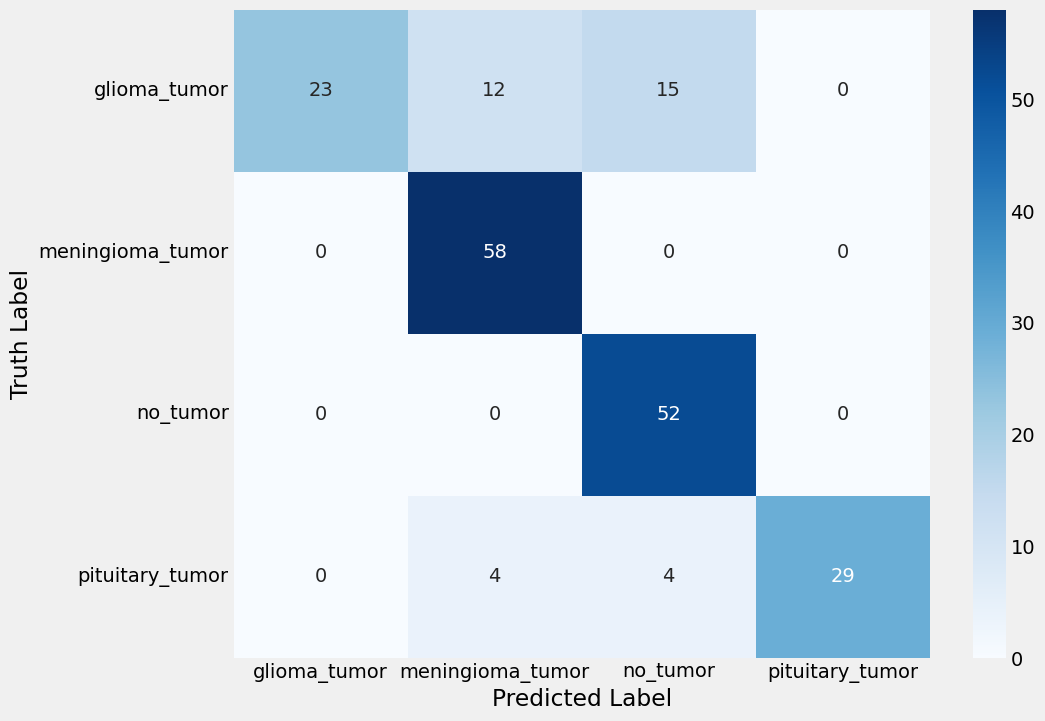

In [28]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [29]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       1.00      0.46      0.63        50
           1       0.78      1.00      0.88        58
           2       0.73      1.00      0.85        52
           3       1.00      0.78      0.88        37

    accuracy                           0.82       197
   macro avg       0.88      0.81      0.81       197
weighted avg       0.87      0.82      0.81       197



In [30]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


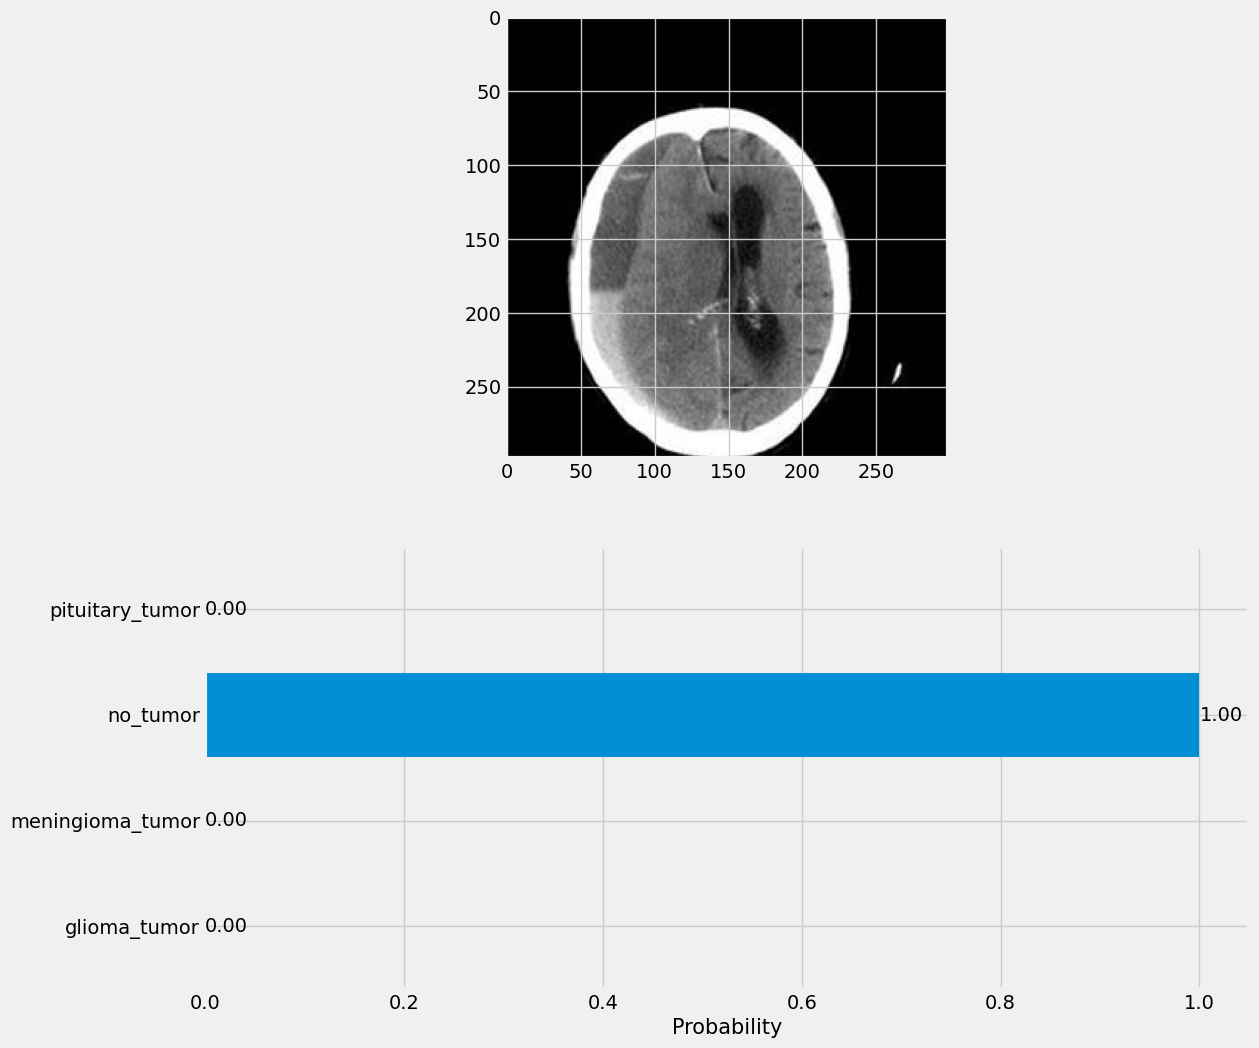

In [31]:
predict('/content/brain_tumor/Testing/no_tumor/image(1).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


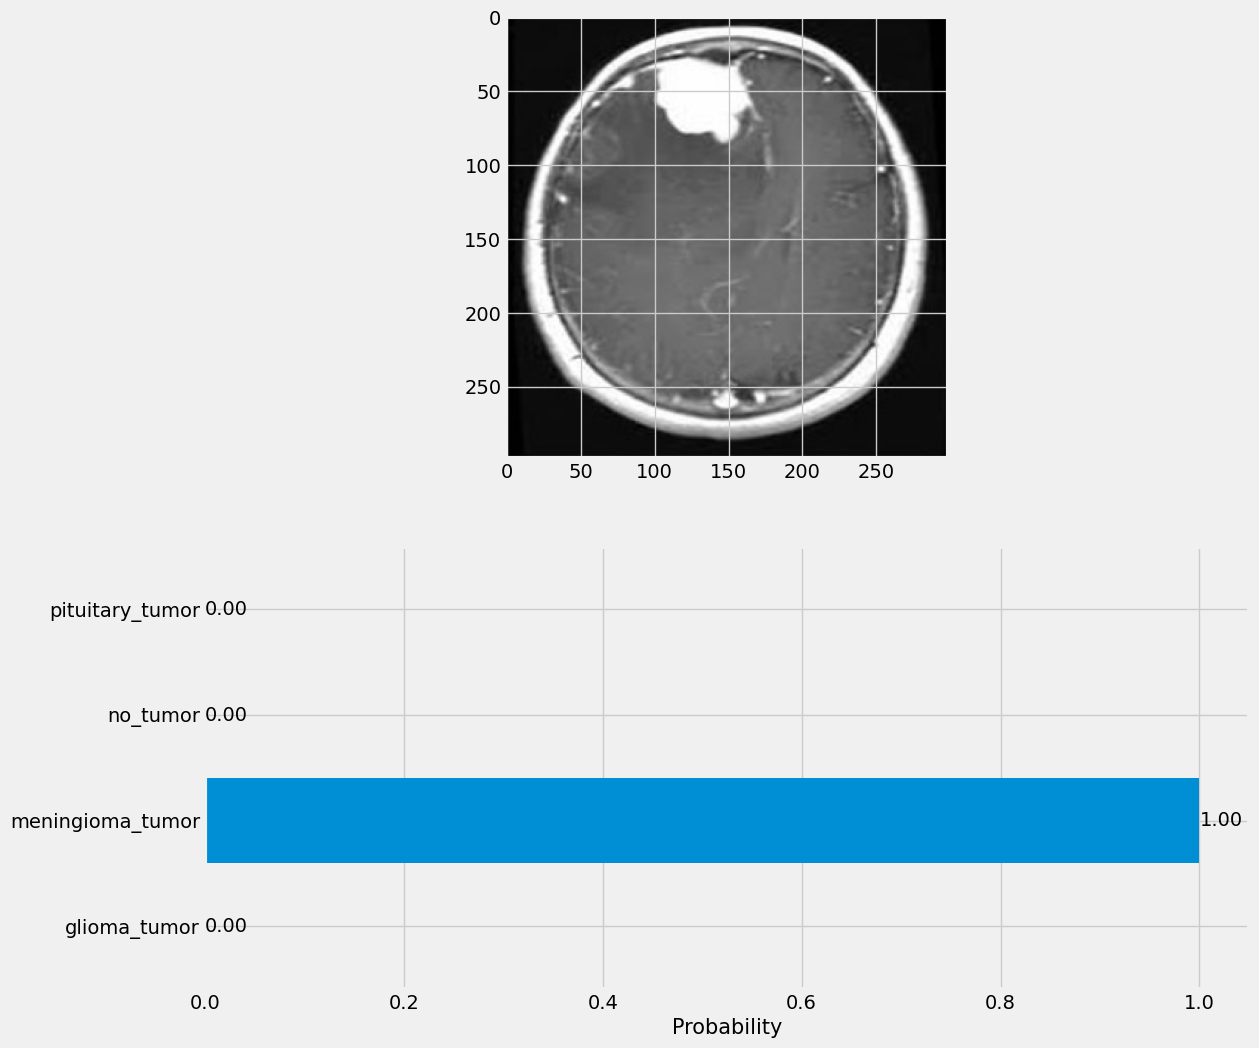

In [32]:
predict('/content/brain_tumor/Testing/meningioma_tumor/image(112).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


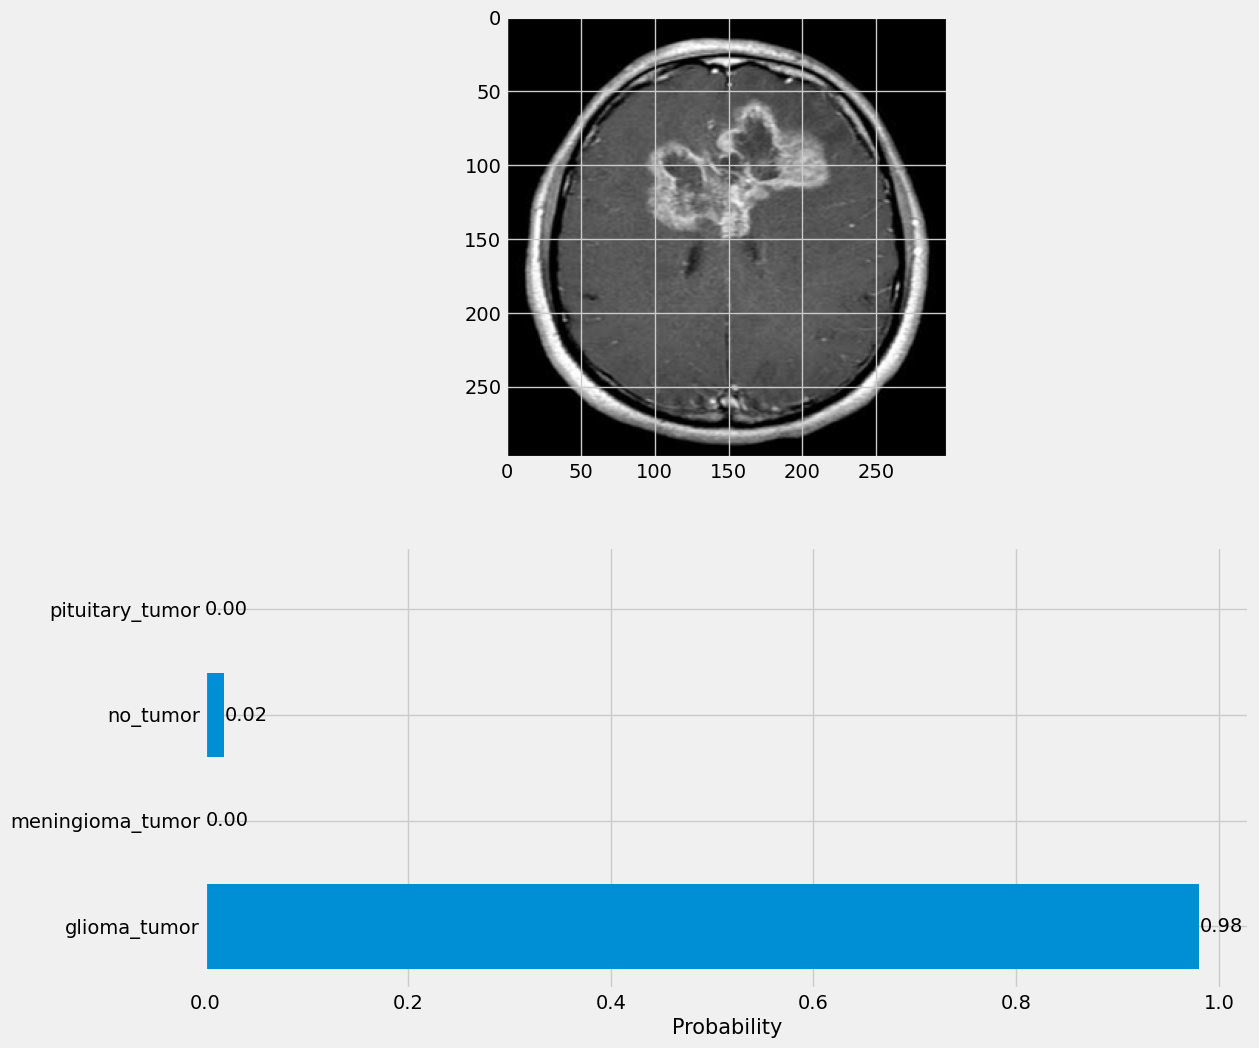

In [34]:
predict('/content/brain_tumor/Testing/glioma_tumor/image(81).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


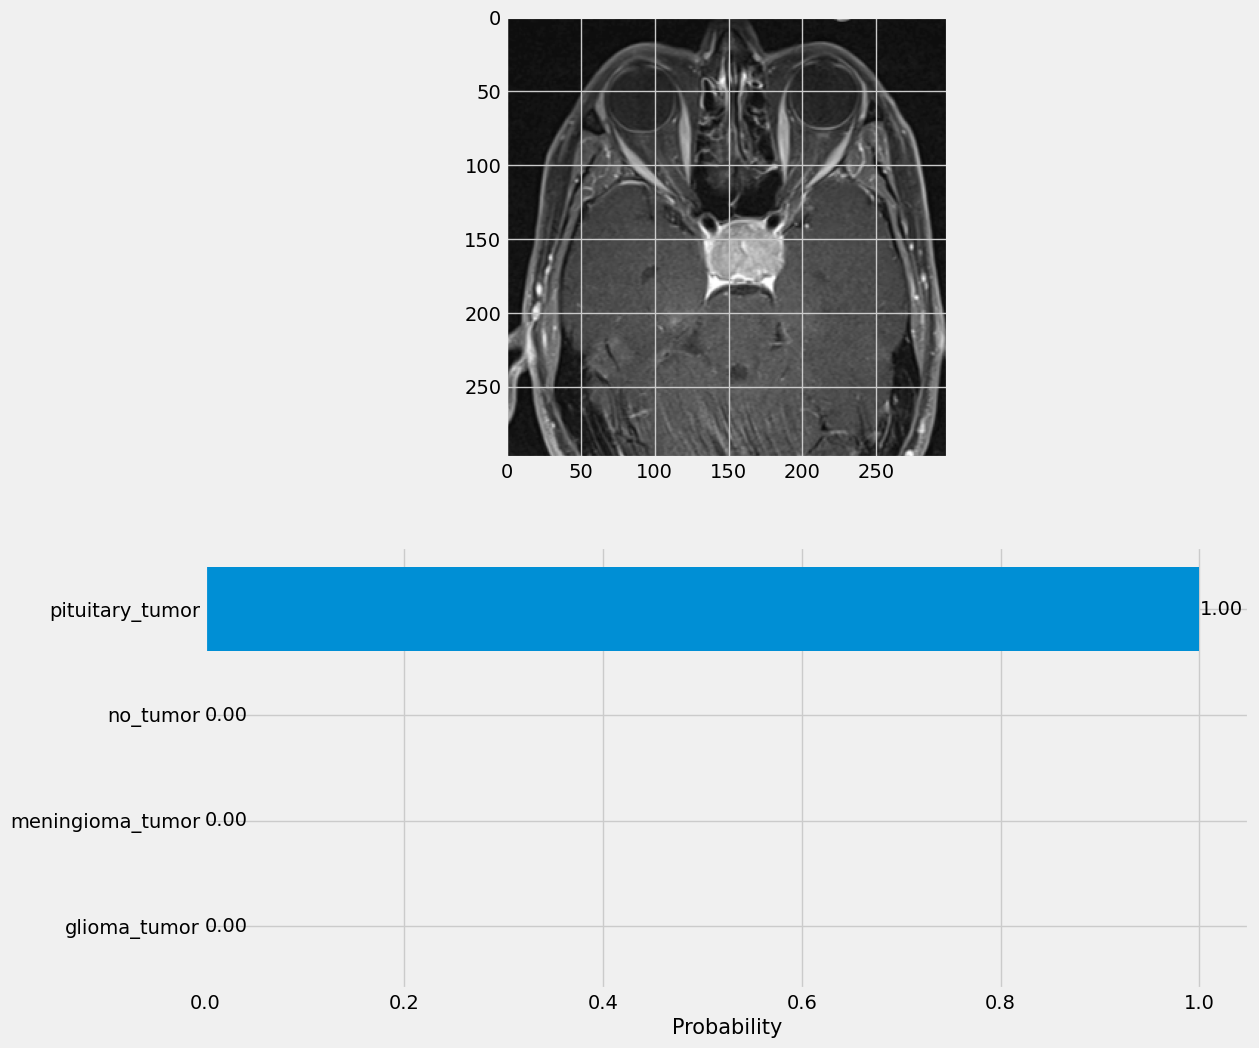

In [35]:
predict('/content/brain_tumor/Testing/pituitary_tumor/image(91).jpg')